# Single Neuron Linear Regression Model
In this notebook, I will implement a single neuron model alongside the gradient descent algorithm, in order to display Linear Regression. We will be using the advertising dataset

## Table of Contents
- Data Preproceesing
- Model Implementation

### Data Preprocessing
1. Import Libraries
2. Read Data
3. Scale Data
4. Data Visualization

#### Import Libraries

In [12]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#### Read Data
Read the Advertising.csv dataset

In [13]:
df = pd.read_csv("Advertising.csv")
df.iloc[:100]

,Index,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
95,96,163.3,31.6,52.9,16.9
96,97,197.6,3.5,5.9,11.7
97,98,184.9,21.0,22.0,15.5
98,99,289.7,42.3,51.2,25.4


#### Scale Data
Here, we scale the data so that every feature is a value between 0 and 1.
We need to do this, so that values with large magnitude don't unduly influence the model.

In [14]:
scaler = MinMaxScaler()
X = scaler.fit_transform(df[["TV", "radio", "newspaper"]])
y = df.sales.values

#### Split Data
Now, we split the data into X_train, y_train, X_test, and y_test sets.
- X sets contain the features that will be input to the models.
- y sets contain the actual output outcomes from the model. 
- train sets will be used to train the data.
- test sets will be used to evaluate the data.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(140, 3)
(60, 3)
(140,)
(60,)


#### Data Visualization
As we can see from the graphs below, the Sales amount seems to increase as the features get larger.
Moreover TV and Radio spend seems very corellated.
In contrast, Radio and Newspaper spend seem uncorelated.

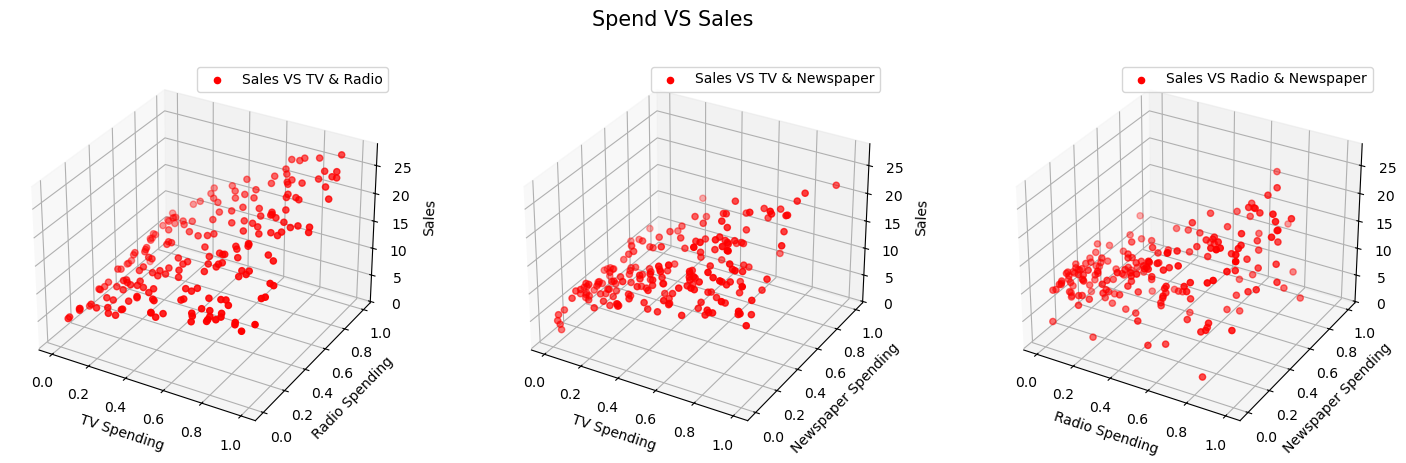

In [16]:
fig = plt.figure(figsize=(18,5))

attr_lst = ["TV", "Radio", "Newspaper"]
k = 0
for k, (i, j) in enumerate([(0,1), (0,2), (1,2)], start=1):
    ax = fig.add_subplot(1, 3, k, projection="3d")
    ax.scatter(X[:, i], X[:, j], y, c="red", label="Sales VS " + attr_lst[i] +" & "+ attr_lst[j])
    ax.set_xlabel(attr_lst[i] + " Spending")
    ax.set_ylabel(attr_lst[j] + " Spending")
    ax.set_zlabel("Sales")
    ax.legend()
    k += 1

fig.suptitle("Spend VS Sales", fontsize=15)
plt.show()

### Model Implementation
Here, we implement our Linear Regression Model

#### Single Neuron Class Implementation
Below is an implementation of a Single Neuron class. It implements gradient descent to fit the given data.
Later, we can specify the activation function to make it a Linear Regression.

In [17]:
class SingleNeuron(object):
    """
    A class used to represent a Single Neuron

    Attributes
    ----------
    inputs : array
        an array of inputs to the perceptron
    outputs : array
        an array of expected outputs from the perceptron
    alpha : float
        the learning rate
    epochs : int
        the number of epochs to train

    Methods
    -------
    train()
        trains the perceptron for self.epoch iterations, to produce self.outputs from self.inputs.

    train_err_limit(self, percent_err, max_epochs=None)
        trains the perceptron until it reaches a certain percent_error rate or until max_epochs are reached.

    update_weights()
        updates the weights of the perceptron(self.w_) once using self.inputs and comparing with self.outputs.

    net_input(inputs):
        calculates the net input to the perceptron, by multiplying a given input with the weights and adding the bias.
    
    predict():
        calculates the output the perceptron produces for a given input.
    
    """
    
    def __init__(self, inputs, outputs, activation_function, alpha = 0.005, epochs = 100):
        if not(isinstance(epochs, int)):
            raise TypeError("epochs must be an integer.")
        if epochs < 1:
            raise ValueError("Epochs must be less than 1")
        if not isinstance(alpha, float):
            raise TypeError("aplha must be a float")
        if not (0 < alpha <= 1):
            raise ValueError("alpha must be between 0 and 1")
        if not isinstance(inputs, np.ndarray) or not isinstance(outputs, np.ndarray):
            raise TypeError("inputs and outputs must be NumPy arrays")
        if inputs.shape[0] != outputs.shape[0]:
            raise ValueError("inputs and outputs must have the same number of samples")
        if len(outputs.shape) != 1:
            raise ValueError("outputs must be a 1D array")
        
        self.activation_function = activation_function 
        self.alpha = alpha
        self.epochs = epochs
        self.inputs = inputs
        self.outputs = outputs
        self.w_ = np.random.rand(1+inputs.shape[1])
        self.errors_ = []
    
    def train(self):
        N = self.inputs.shape[0]

        for _ in range(self.epochs):
            errors = 0
            for xi, target in zip(self.inputs, self.outputs):
                error = self.predict(xi) - target
                self.w_[:-1] -= self.alpha * error * xi
                self.w_[-1] -= self.alpha * error
                errors += 0.5 * (error ** 2)

            
            self.errors_.append(errors/N)
        return
    def predict(self, X):
        preactivation = np.dot(X, self.w_[:-1]) + self.w_[-1]
        return self.activation_function(preactivation)

#### Training Model with Linear Activation
We train our model with a linear activation in order to implement linear regression

In [18]:
def linear_activation(z):
    return z
node = SingleNeuron(X_train, y_train,  linear_activation)
node.train()

### Model Evaluation
Here, we look at how our model performs on data it has never seen before, after training on similar data.

#### Error Metrics
- MSE and RMSE provide a quantitative measure of prediction errors.
- MAE shows average absolute error magnitude.
- R² reflects the proportion of variance explained by the model. A value closer to 1 indicates a better fit.
- These metrics together give a view of how well the linear regression model performs on unseen data

In [19]:
y_pred = node.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean squared error:      {mse}")
print(f"Root Mean Squared error: {rmse}")
print(f"Mean Absolute error:     {mae}")
print(f"R2 score:                {r2}")

Mean squared error:      2.5699308775831287
Root Mean Squared error: 1.603100395353681
Mean Absolute error:     1.3058369122678763
R2 score:                0.9134053138173133


#### Plot Expected VS Predicted Sales
In the figure below, we plot the difference between Expected and predicted sales.

Ideally, we want the predicted sales (blue points) to be close to the actual sales(red line).

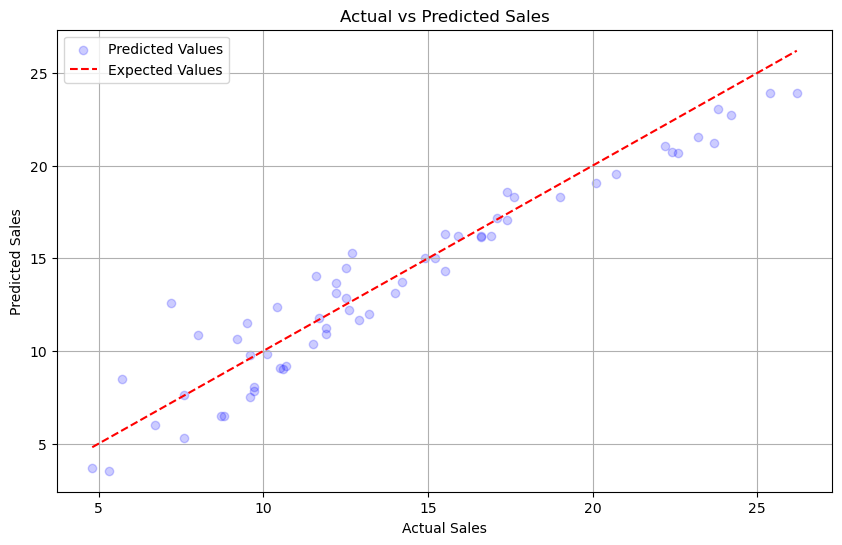

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, c='blue', alpha=0.2, label='Predicted Values')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label='Expected Values')  # Line y = x
plt.grid(True)
plt.legend()
plt.show()

#### Residual Plot
A Residual is the difference between the expected and predicted value. In an ideal world, we would have a residual of 0. However in practice, this is often not true. Below, I plot a graph where each blue point is (predicted, residual). The red line running through the center represents the ideal case, where there are no errors.

For the residual (y-axis): 
- Positive values $\rightarrow$ prediction too low
- Negative values $\rightarrow$ prediction was too high
- 0 $\rightarrow$ correct prediction

In general, we want residual plots with the following properties:
- Symmetric distribution clustered towards middle of plot
- Close to 0 y value e.g(0.3 or -1.2, not 60 or 200)
- No clear patterns

The residual plot for our model indicates:
- Our model performs best in the mid-range of predicted sales, but struggles to accurately predict low and high sales level(increased pread of residuals).
- Random scatter shows that our model isn't systemically biased
- But, the plot does suggest that  residual plot indicates your model performs best in the mid-range of predicted sales, but struggles to predict accurately at low and high sales levels (increased spread of residuals)
- Random scatter suggests the model isn’t systematically biased
- Larger residuals at extremes (both low and high predicted sales) indicate the model struggles with observations far from the central sales range - maybe the true relationship between the features (TV, radio, newspaper spending) and sales is not strictly linear.
- There is one outlier value which has a very large residual value. We may benefit from removing such outliers when training, so our model better approximates the vast majority of the inputs

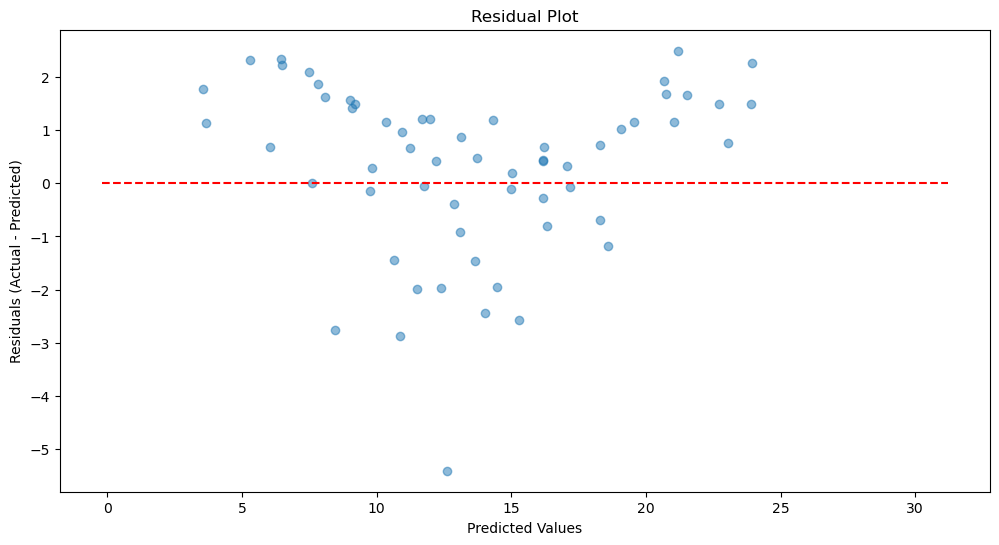

In [21]:
residual = y_test - y_pred

plt.figure(figsize=(12,6))
plt.hlines(0, min(y_test)-5, max(y_test)+5, colors='r', linestyles= 'dashed', label='Zero Line Error')
plt.scatter(y_pred, residual, alpha=0.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()